In [1]:
from detection_helper import *

In [2]:
times_arr, freq_arr, data_arr = return_arr('2023-08-19', '2023-08-20')

10-Feb-26 19:33:22: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
10-Feb-26 19:33:23: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230819_v03.cdf
10-Feb-26 19:33:23: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
10-Feb-26 19:33:24: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230819_v03.cdf
10-Feb-26 19:33:24: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
10-Feb-26 19:33:24: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230819_v03.cdf
10-Feb-26 19:33:24: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
10-Feb-26 19:33:24: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230819_v03.cdf


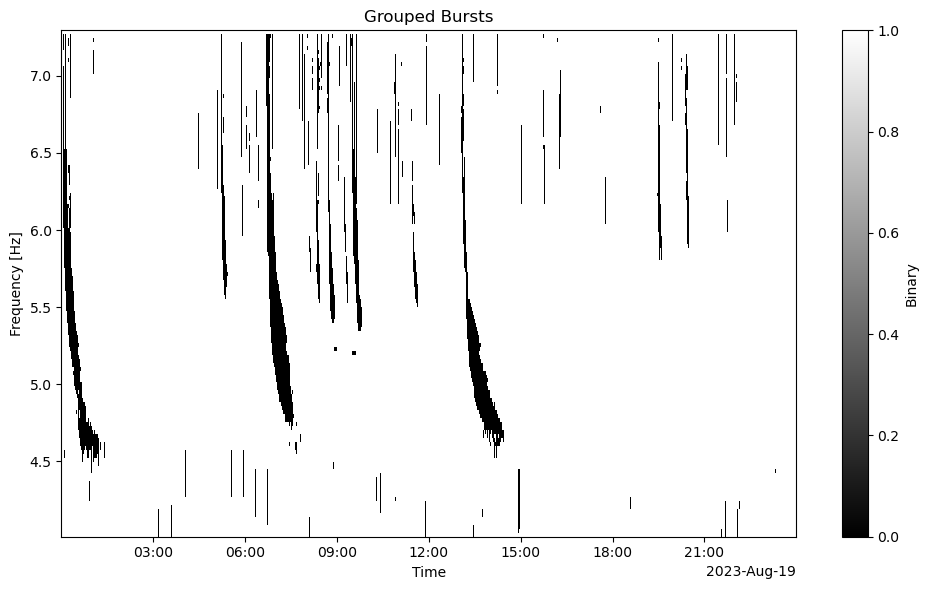

In [3]:
freq_log, freq_log_exp, data_arr_log = convert_data_log(freq_arr, data_arr)
bmap = bmap_row_mean_loop_new(times_arr=times_arr, full_data=data_arr_log, min_duration=1)
plot_bmap(times_arr, freq_log_exp, bmap)

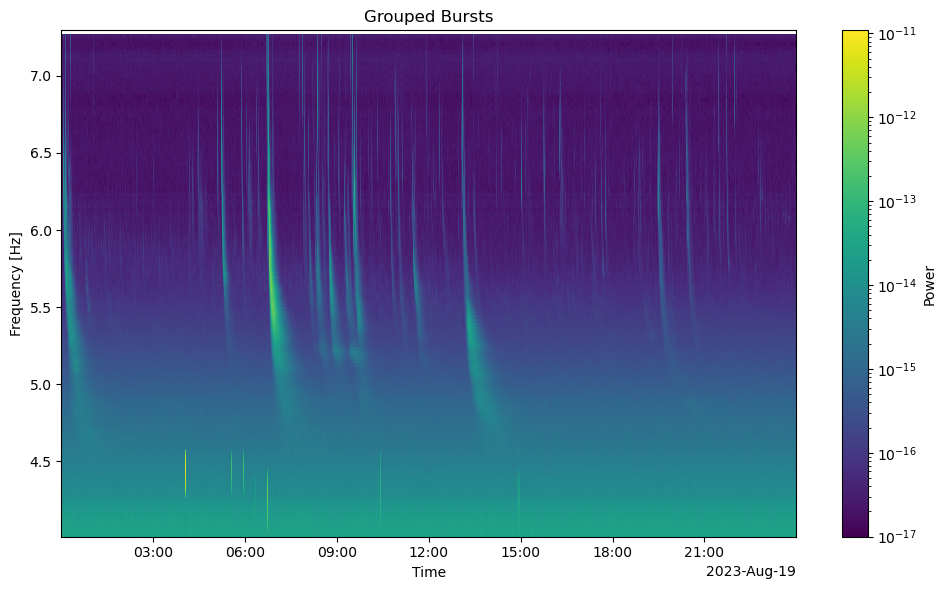

In [4]:
plot_spectrum(times_arr, freq_log_exp, data_arr_log)

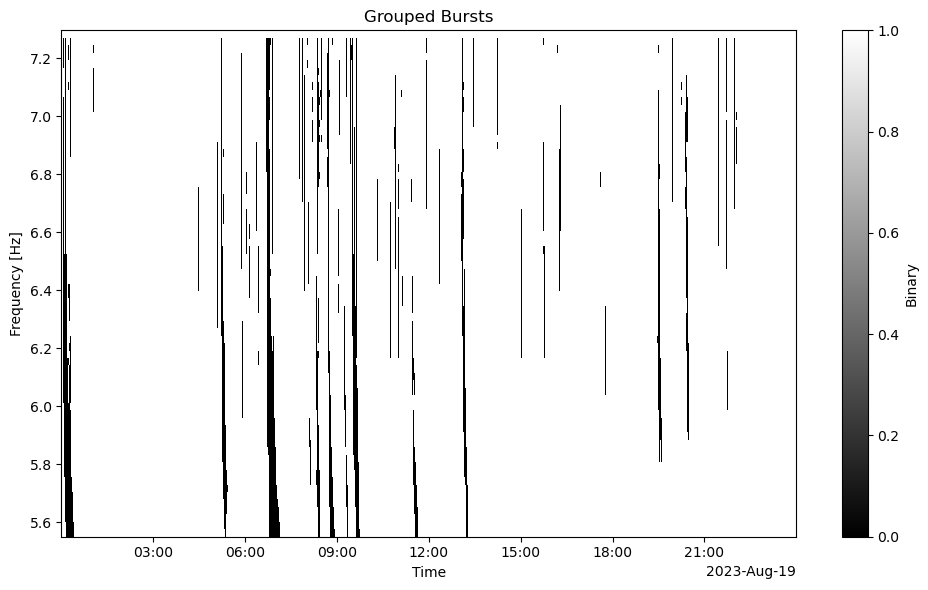

In [5]:
plot_bmap(times_arr, freq_log_exp[60:], bmap[:, 60:])

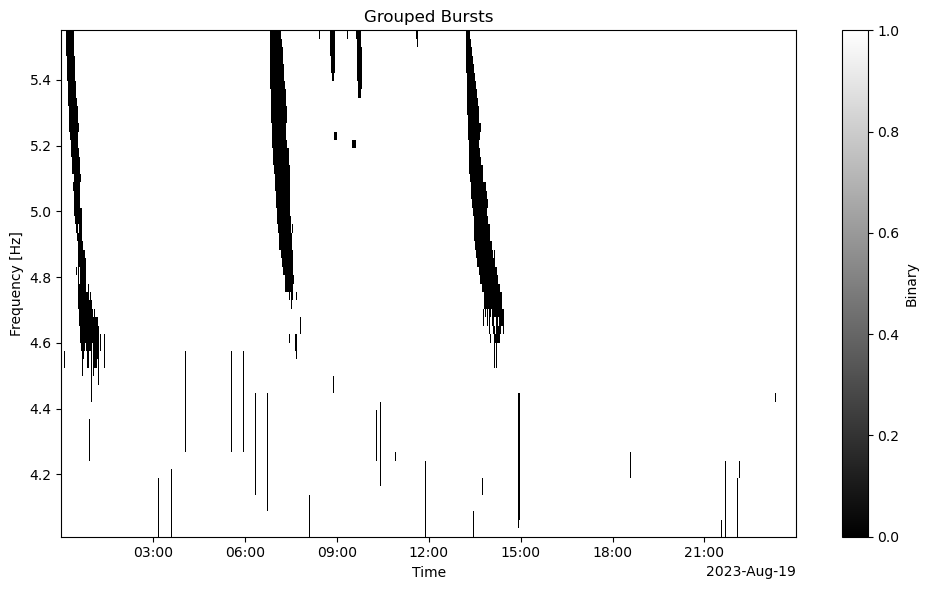

In [6]:
plot_bmap(times_arr, freq_log_exp[:60], bmap[:, :60])

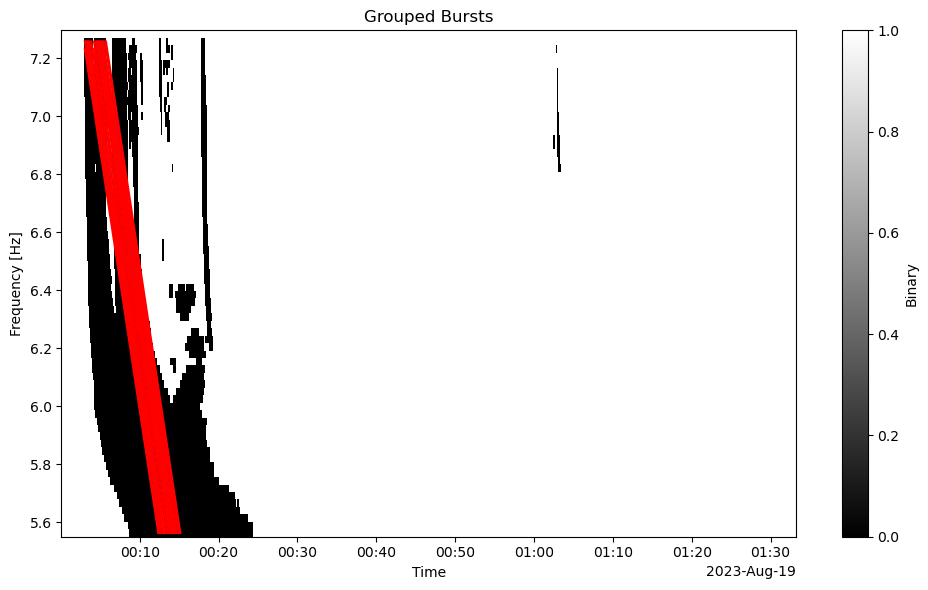

In [7]:
theta=np.deg2rad(np.linspace(39, 40, 120))
lines_high = hough_detect(bmap[:800, 60:], data_arr_log[:800,:], threshold=1, line_gap=10, line_length=80, theta=theta)
plot_bmap(times_arr[:800], freq_log_exp[60:], bmap[:800, 60:], lines_high)

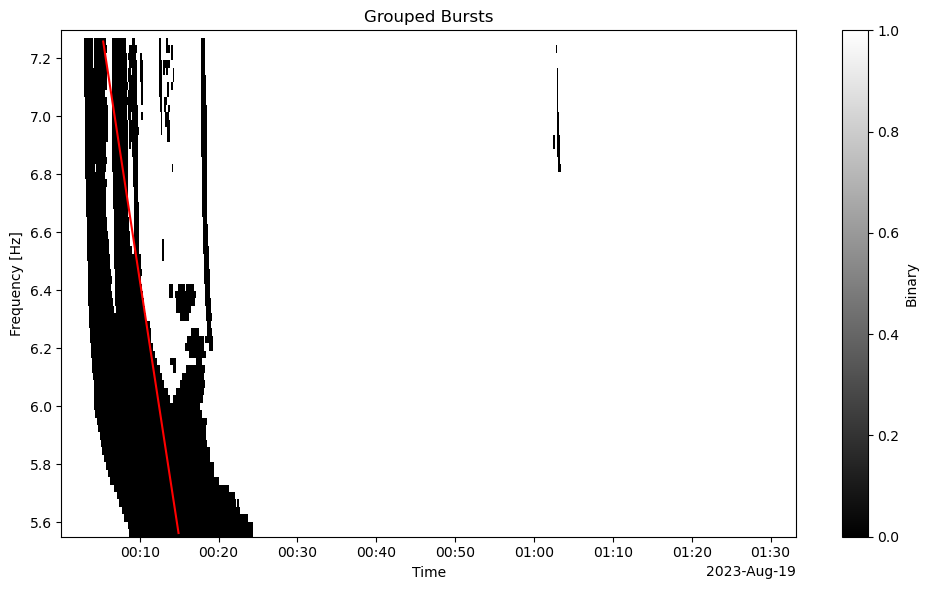

In [8]:
longest_line_high, longtest_line_length_high = longest_line(lines_high)
plot_bmap(times_arr[:800], freq_log_exp[60:], bmap[:800, 60:], [longest_line_high])

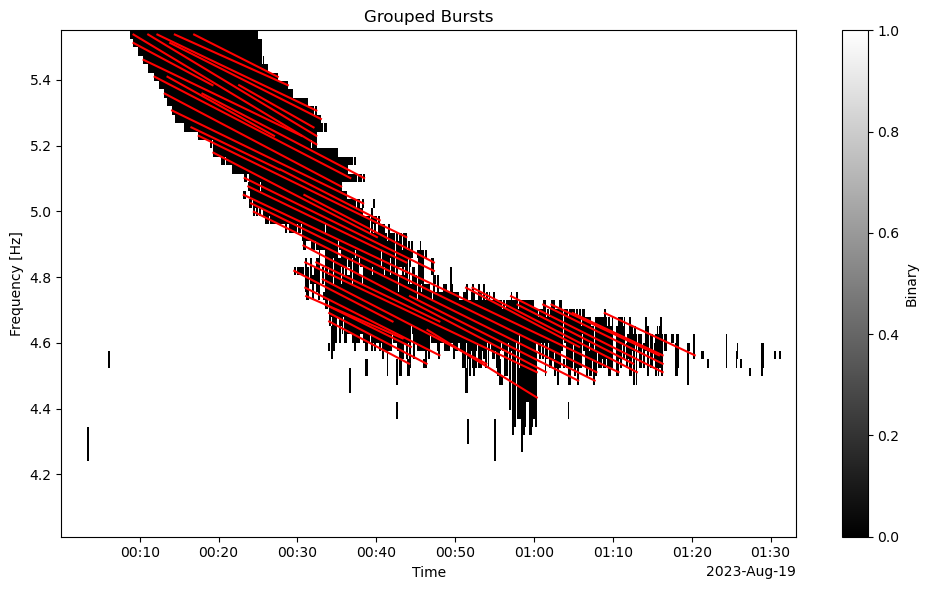

In [41]:
theta=np.deg2rad(np.linspace(3, 4, 120))
lines_low = hough_detect(bmap[:800, :60], data_arr_log[:800,:], threshold=1, line_gap=10, line_length=80, theta=theta)
plot_bmap(times_arr[:800], freq_log_exp[:60], bmap[:800, :60], lines_low)

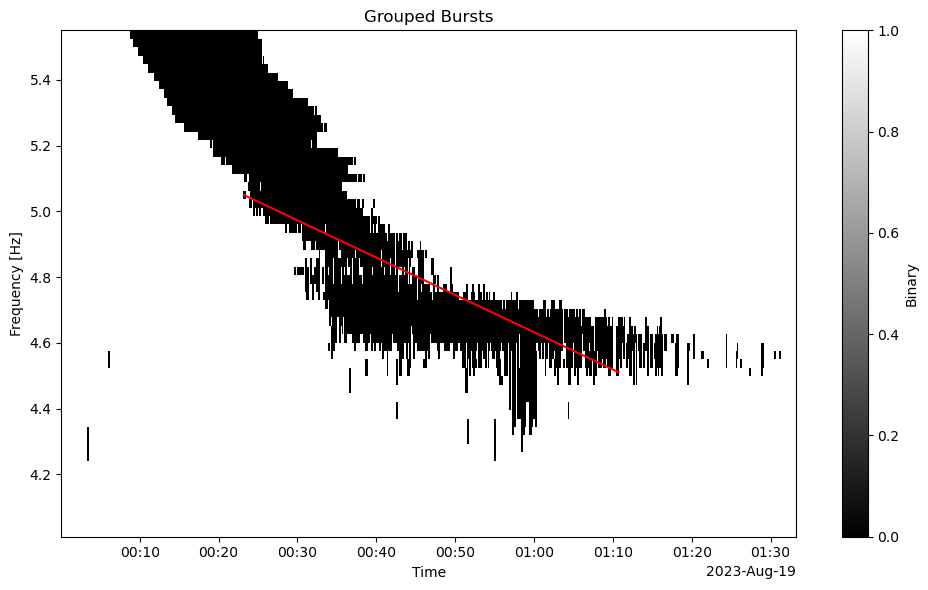

In [43]:
longest_line_low, longtest_line_length_low = longest_line(lines_low)
plot_bmap(times_arr[:800], freq_log_exp[:60], bmap[:800, :60], [longest_line_low])

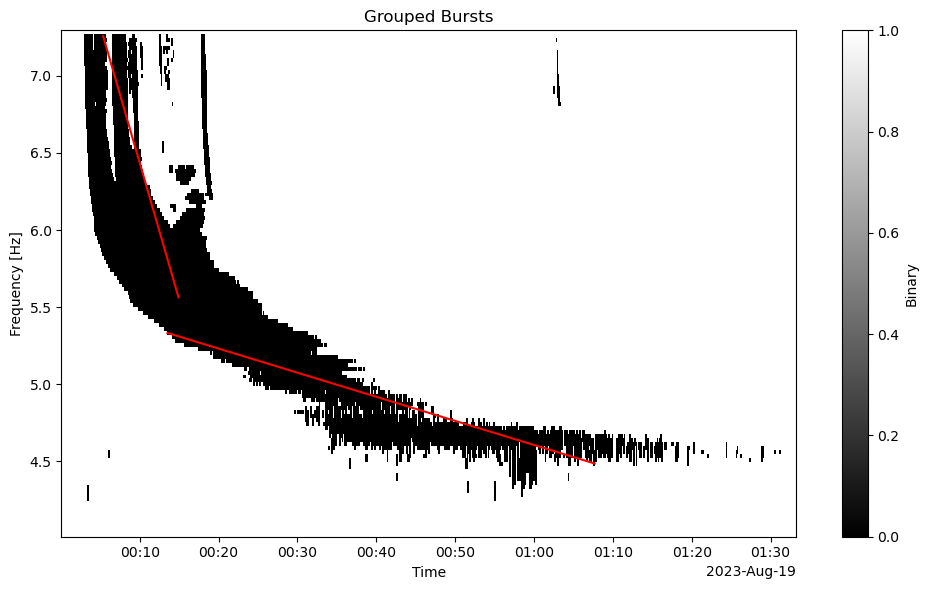

In [11]:
(x1, y1), (x2, y2) = longest_line_high
longest_line_high = ((x1 + 60, y1), (x2 + 60, y2))

plot_bmap(times_arr[:800], freq_log_exp, bmap[:800], [longest_line_low, longest_line_high])

In [12]:
def plot_line_slice(bmap, times_arr, freq_log_exp, data_arr_log, x_slice=[0,800], y_slice=60):
    # y_slice is the index that seperate high and low
    
    x_slice_start = x_slice[0]
    x_slice_stop = x_slice[1]
    bmap_slice = bmap[x_slice_start:x_slice_stop]
    times_arr_slice = times_arr[x_slice_start:x_slice_stop]
    data_arr_log_slice = data_arr_log[x_slice_start:x_slice_stop]
    
    theta=np.deg2rad(np.linspace(39, 40, 120))
    lines_high = hough_detect(bmap_slice[:, y_slice:], data_arr_log_slice, threshold=1, line_gap=70, line_length=80, theta=theta)
    longest_line_high, longtest_line_length_high = longest_line(lines_high)
    
    theta=np.deg2rad(np.linspace(4, 5, 120))
    lines_low = hough_detect(bmap_slice[:, :y_slice], data_arr_log_slice, threshold=1, line_gap=70, line_length=80, theta=theta)
    longest_line_low, longtest_line_length_low = longest_line(lines_low)

    if (longest_line_high is not None) and (longest_line_low is not None):
        print('pass')
        (x1, y1), (x2, y2) = longest_line_high
        longest_line_high = ((x1 + y_slice, y1), (x2 + y_slice, y2))
    
        (x1, y1), (x2, y2) = longest_line_low
        longest_line_low = ((x1, y1), (x2, y2))
        
        plot_bmap(times_arr_slice, freq_log_exp, bmap_slice, [longest_line_low, longest_line_high])
        return longest_line_low, longest_line_high
    else:
        return None, None

pass


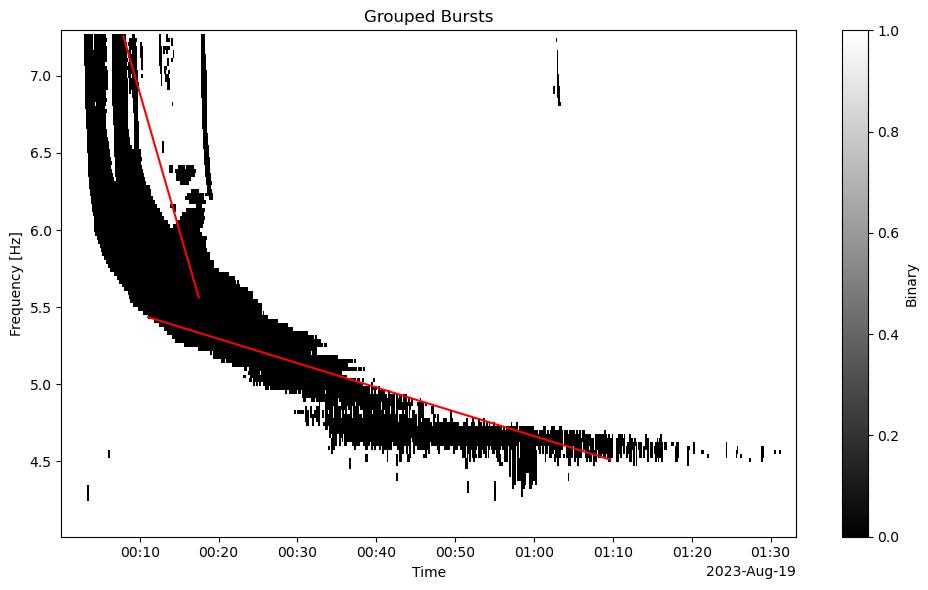

In [13]:
longest_line_low, longest_line_high = plot_line_slice(bmap, times_arr, freq_log_exp, data_arr_log)

pass


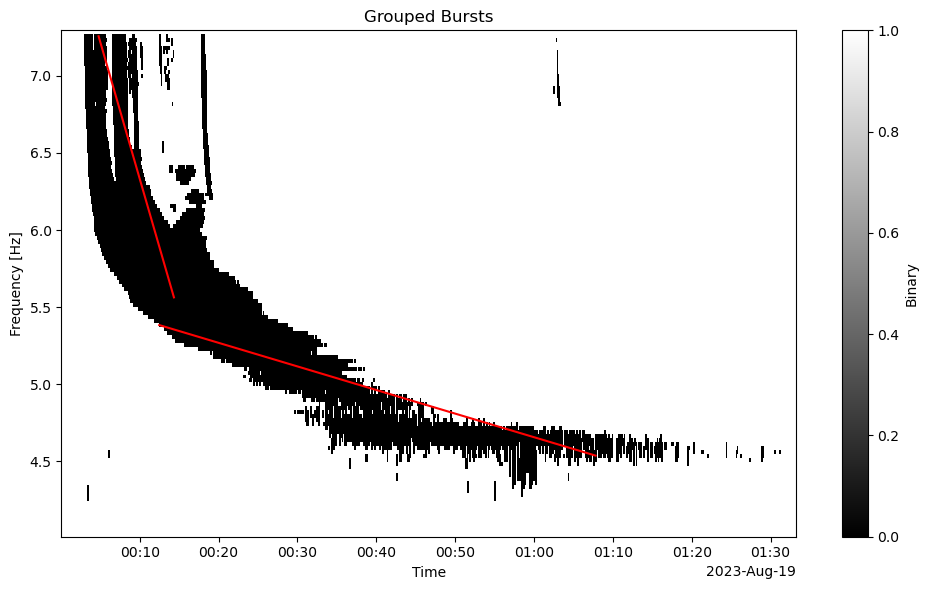

pass


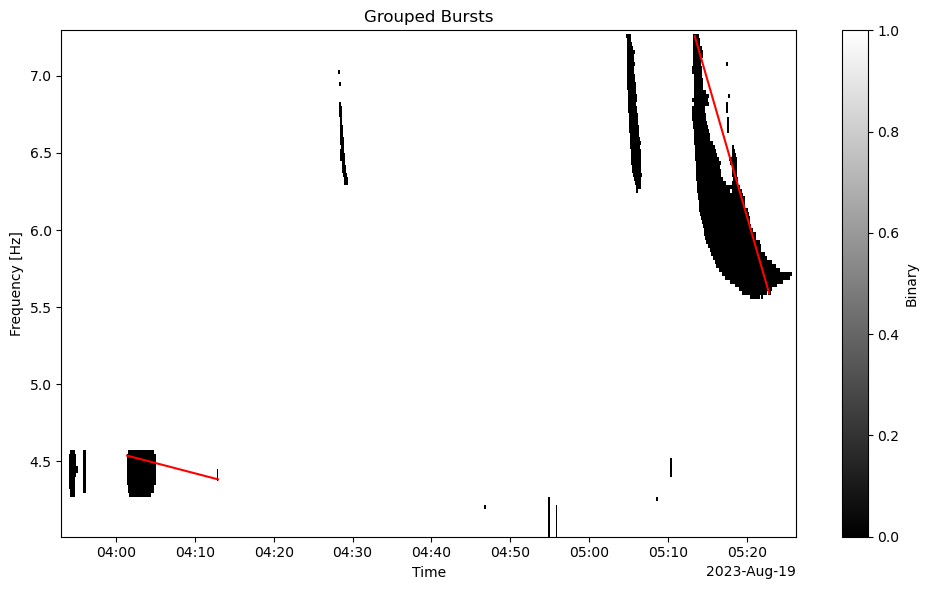

pass


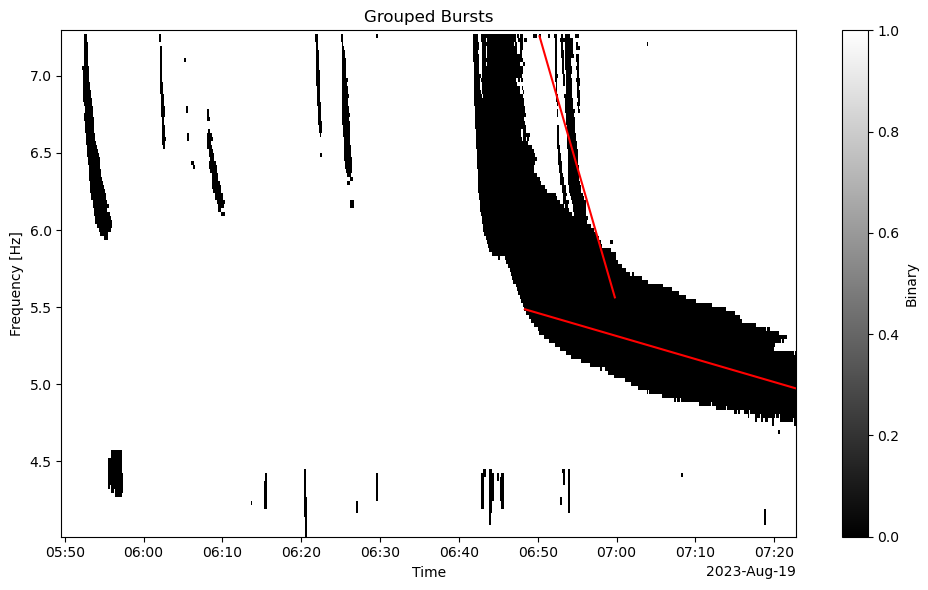

pass


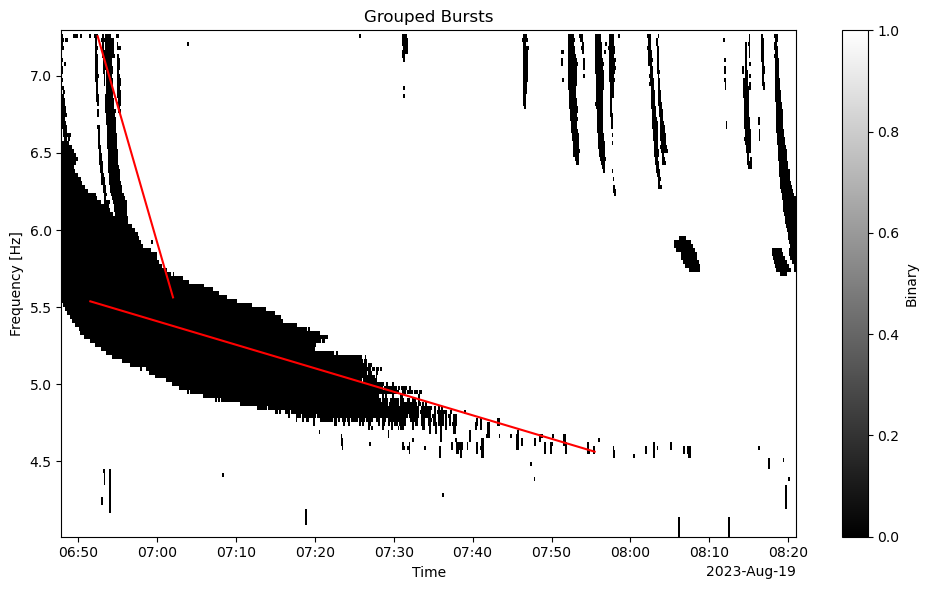

pass


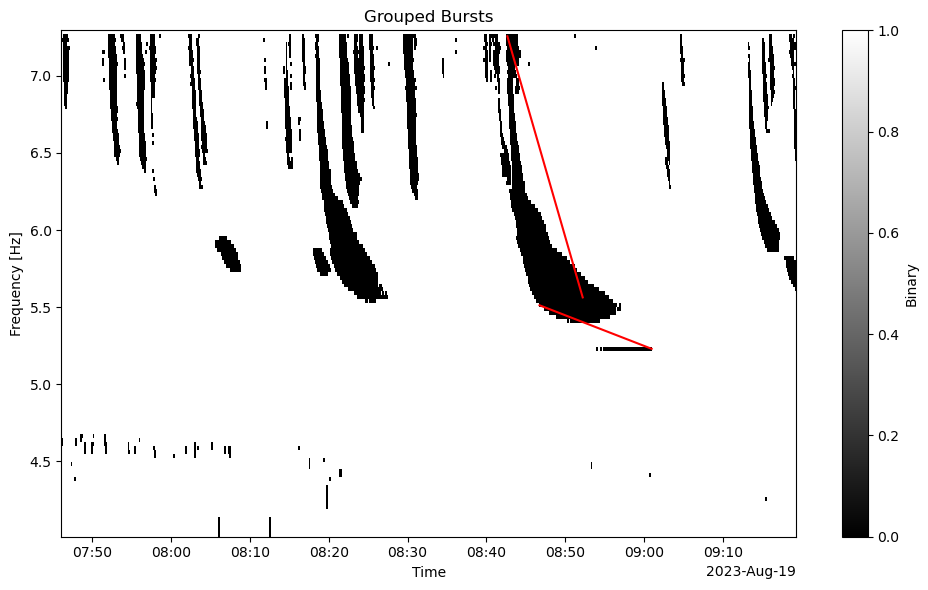

pass


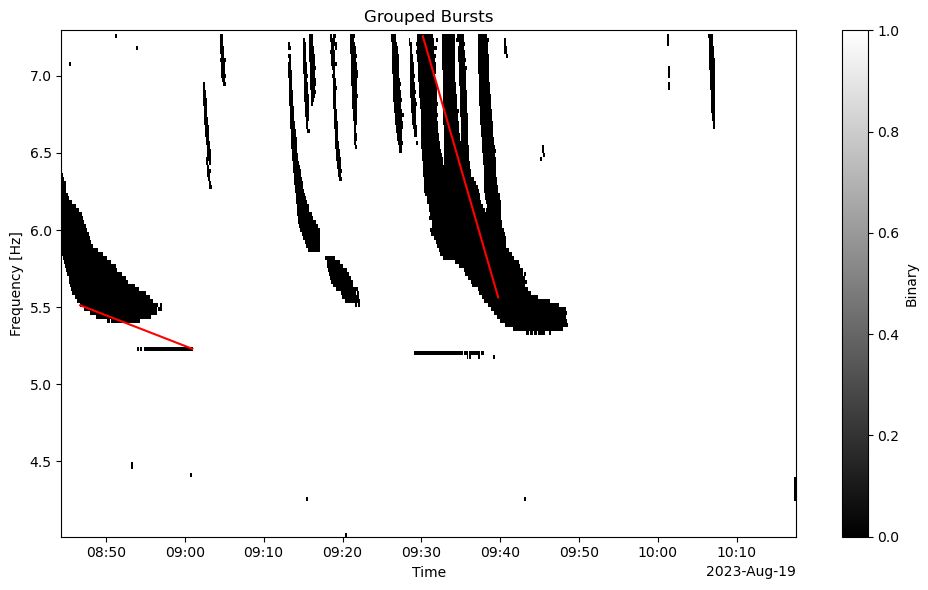

pass


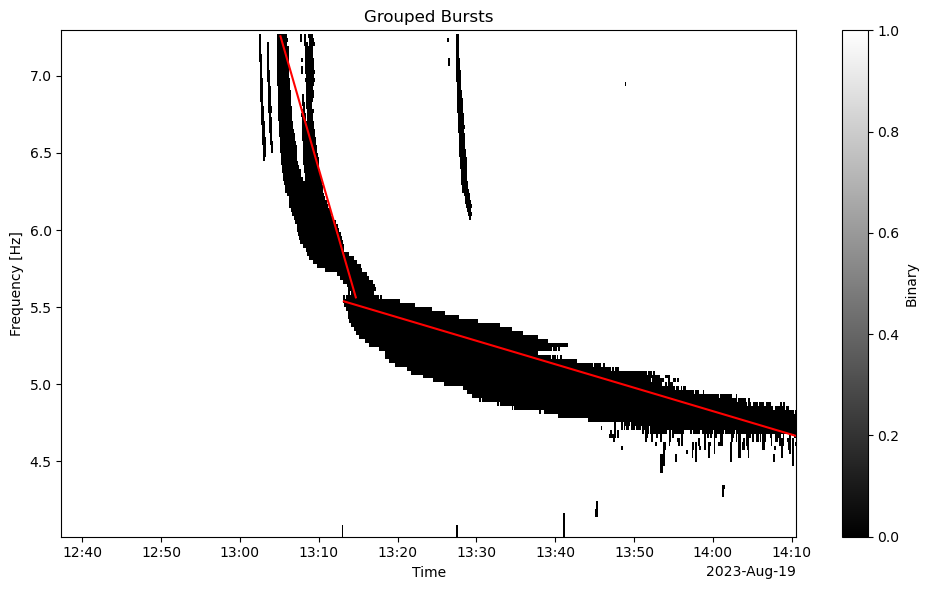

In [14]:
i = 0
lines = []
while i < (len(times_arr)-501):
    longest_line_low, longest_line_high = plot_line_slice(bmap, times_arr, freq_log_exp, data_arr_log, x_slice = [0+i,800+i])
    if (longest_line_high is not None) and (longest_line_low is not None):
        (x1, y1), (x2, y2) = longest_line_high
        longest_line_high = ((x1, y1+i), (x2, y2+i))
        
        (x1, y1), (x2, y2) = longest_line_low
        longest_line_low = ((x1, y1+i), (x2, y2+i))
        lines.append(longest_line_high)
        lines.append(longest_line_low)
    i = i + 500

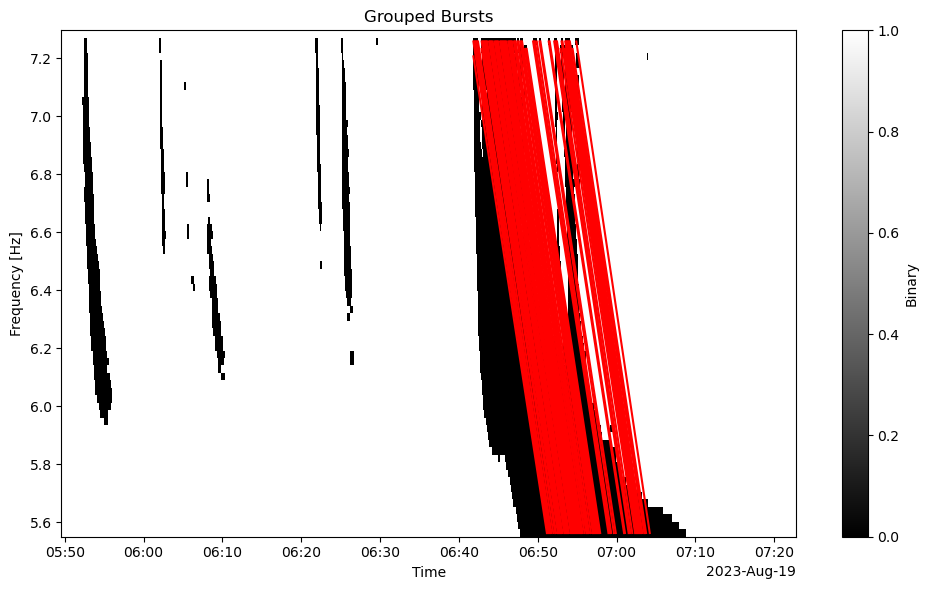

In [15]:
theta=np.deg2rad(np.linspace(39, 40, 120))
lines_high = hough_detect(bmap[3000:3800, 60:], data_arr_log[3000:3800,:], threshold=1, line_gap=70, line_length=80, theta=theta)
plot_bmap(times_arr[3000:3800], freq_log_exp[60:], bmap[3000:3800, 60:], lines_high)

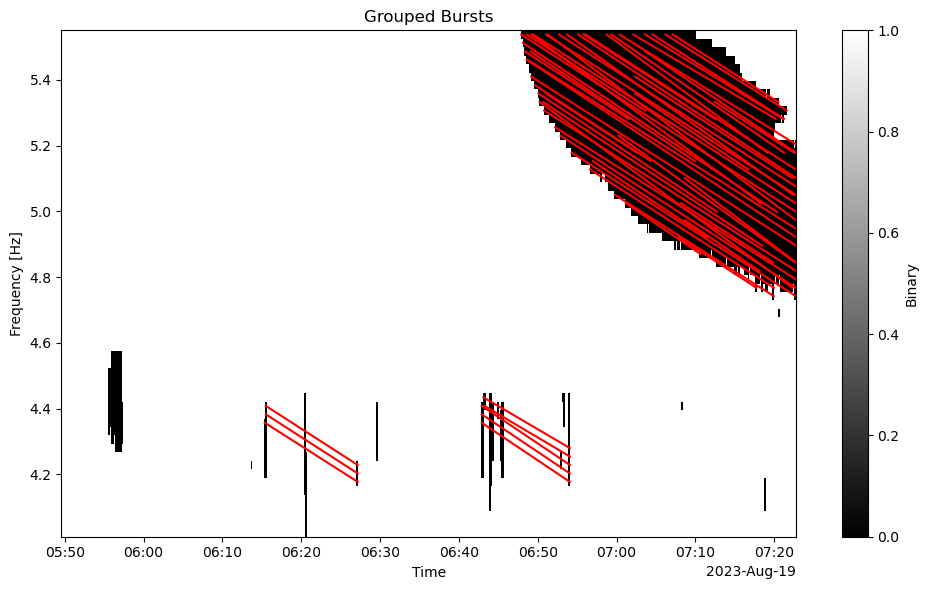

In [16]:
theta=np.deg2rad(np.linspace(4, 5, 120))
lines_low = hough_detect(bmap[3000:3800, :60], data_arr_log[3000:3800,:], threshold=1, line_gap=70, line_length=80, theta=theta)
plot_bmap(times_arr[3000:3800], freq_log_exp[:60], bmap[3000:3800, :60], lines_low)

In [17]:
lines

[((60, 122), (126, 40)),
 ((20, 581), (53, 106)),
 ((61, 2770), (126, 2689)),
 ((14, 2170), (20, 2071)),
 ((60, 3602), (126, 3520)),
 ((37, 3799), (57, 3504)),
 ((60, 3621), (126, 3539)),
 ((21, 4080), (59, 3531)),
 ((60, 4567), (126, 4485)),
 ((47, 4642), (58, 4520)),
 ((60, 4975), (126, 4893)),
 ((47, 4642), (58, 4520)),
 ((60, 6820), (126, 6738)),
 ((25, 7299), (59, 6807))]

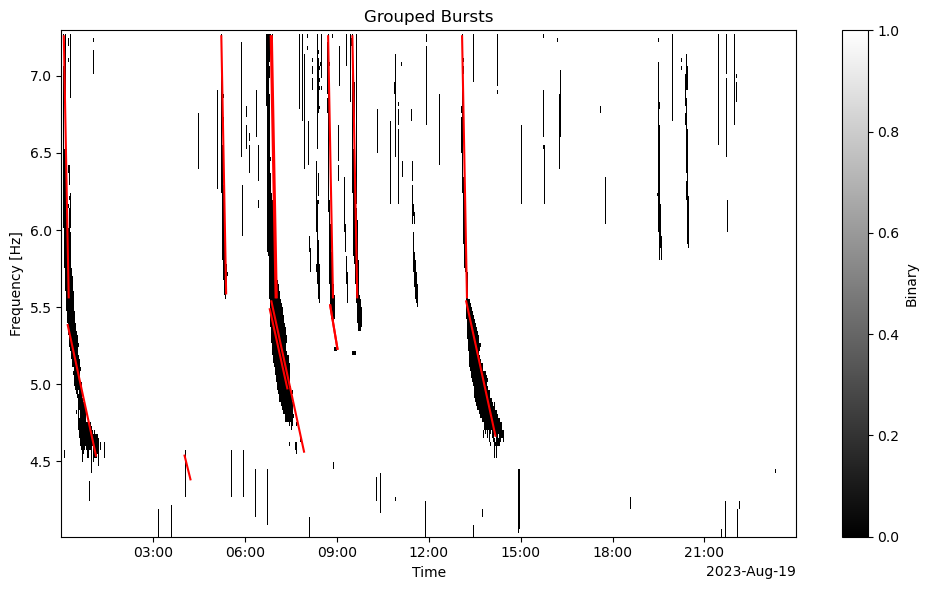

In [18]:
plot_bmap(times_arr, freq_log_exp, bmap, lines)